# 04 — Evaluation and Error Analysis

## Metrics
All metrics are reported in **basis points** on the held-out test set
(last 20% of bars — never touched during training or validation).

| Metric | Description |
|--------|-------------|
| MAE    | Mean absolute error — primary metric, directly interpretable |
| RMSE   | Root mean squared error — emphasises large errors |
| MedAE  | Median absolute error — robust to outliers |

## Baselines
1. **Mean predictor** — always predicts training-set mean slippage
2. **Linear (Ridge)** — same features, linear model
3. **Heuristic** — β × order_size_fraction × vol_rolling, β calibrated on val

## Error analysis segments
Order size (Q1–Q4) · Volatility (Q1–Q4) · Time of day (open/mid/close) · Buy vs sell · Volume regime

In [1]:
import sys, pathlib, json
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))

import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt

from features import FEATURE_NAMES
from pipeline import build_full_dataset
from model import SlippageMLP
from train import predict
from baselines import MeanPredictor, LinearBaseline, HeuristicBaseline
from evaluate import global_metrics, segment_breakdown
from paths import RESULTS_DIR
from viz import (
    plot_pred_vs_actual,
    plot_error_by_segment,
    plot_feature_importance,
    FIGURES_DIR,
)

In [2]:
# Rebuild data and split via the shared pipeline. split.test_df is
# guaranteed to align row-by-row with split.y_test / X_test.
data, proxy_all, split = build_full_dataset()
n_tr, n_v, n_te = len(split.X_train), len(split.X_val), len(split.X_test)
print(f'Train: {n_tr:,}  Val: {n_v:,}  Test: {n_te:,}')

test_df = split.test_df  # no more iloc tricks

[data] SPY: 3439 bars (2024-06-03 → 2026-05-22)
[data] QQQ: 3421 bars (2024-06-03 → 2026-05-22)
[data] AAPL: 3433 bars (2024-06-03 → 2026-05-22)
[data] MSFT: 3433 bars (2024-06-03 → 2026-05-22)
[data] NVDA: 3431 bars (2024-06-03 → 2026-05-22)
[data] AMZN: 3440 bars (2024-06-03 → 2026-05-22)
[data] GOOGL: 3438 bars (2024-06-03 → 2026-05-22)
[data] META: 3431 bars (2024-06-03 → 2026-05-22)
[data] JPM: 3441 bars (2024-06-03 → 2026-05-22)
Train: 39,933  Val: 9,215  Test: 12,288


In [3]:
# Load trained model
checkpoint = torch.load(RESULTS_DIR / 'model_checkpoint.pt', weights_only=True)
model = SlippageMLP(n_features=checkpoint['n_features'])
model.load_state_dict(checkpoint['state_dict'])
y_pred_mlp = predict(model, split.X_test)
y_test = split.y_test

In [4]:
# Fit baselines
mean_pred = MeanPredictor().fit(split.X_train, split.y_train)
linear_pred = LinearBaseline().fit(split.X_train, split.y_train)
heuristic = HeuristicBaseline(FEATURE_NAMES)
heuristic.fit(split.X_val, split.y_val, split.scaler.mean_, split.scaler.scale_)

y_pred_mean = mean_pred.predict(split.X_test)
y_pred_linear = linear_pred.predict(split.X_test)
y_pred_heuristic = heuristic.predict(split.X_test, split.scaler.mean_, split.scaler.scale_)

In [5]:
# Global metrics table
metrics = {
    'MLP': global_metrics(y_test, y_pred_mlp),
    'Linear': global_metrics(y_test, y_pred_linear),
    'Heuristic': global_metrics(y_test, y_pred_heuristic),
    'Mean': global_metrics(y_test, y_pred_mean),
}
metrics_df = pd.DataFrame(metrics).T
print('=== Global Metrics (test set, bps) ===')
print(metrics_df.round(2).to_string())

with open(RESULTS_DIR / 'metrics.json', 'w') as f:
    json.dump({k: {kk: round(vv, 4) for kk, vv in v.items()} for k, v in metrics.items()}, f, indent=2)

=== Global Metrics (test set, bps) ===
           mae_bps  rmse_bps  med_ae_bps
MLP          25.97     52.84       13.44
Linear       25.99     52.84       13.46
Heuristic    25.97     52.85       13.43
Mean         26.05     52.86       13.50


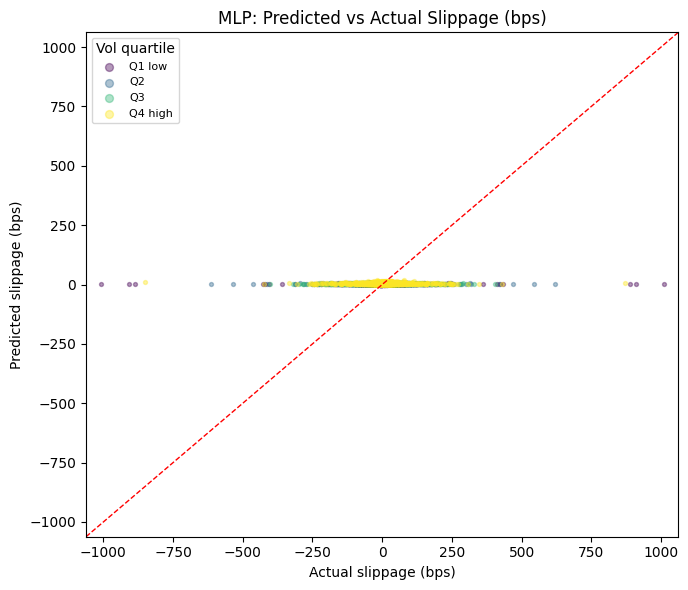

In [6]:
# Predicted vs actual — coloured by vol regime
vol_q = pd.qcut(test_df['vol_rolling'], q=4, labels=['Q1 low', 'Q2', 'Q3', 'Q4 high'])
fig = plot_pred_vs_actual(
    y_test, y_pred_mlp,
    regime=vol_q.values,
    regime_label='Vol quartile',
    title='MLP: Predicted vs Actual Slippage (bps)',
    save_as='pred_vs_actual.png',
)
plt.show()

      segment         bucket  n_samples   mae_bps   rmse_bps  med_ae_bps
size_quartile       Q1_small       3072 26.092284  53.145071   13.332216
size_quartile             Q2       3072 25.427068  48.081671   13.286973
size_quartile             Q3       3072 27.473445  61.347886   13.509914
size_quartile       Q4_large       3072 24.867231  47.612299   13.721455
 vol_quartile     Q1_low_vol       3072 23.599958  60.051713   10.353069
 vol_quartile             Q2       3072 25.162983  50.923371   12.939208
 vol_quartile             Q3       3072 25.889817  45.879763   14.084598
 vol_quartile    Q4_high_vol       3072 29.207269  53.501299   17.002397
  time_of_day           open       1764 21.957088  30.047773   16.739692
  time_of_day            mid       8766 14.280150  19.693018   10.832370
  time_of_day          close       1758 88.251369 129.125831   67.667657
         side            buy       6144 25.964579  52.820472   13.488685
         side           sell       6144 25.965434  

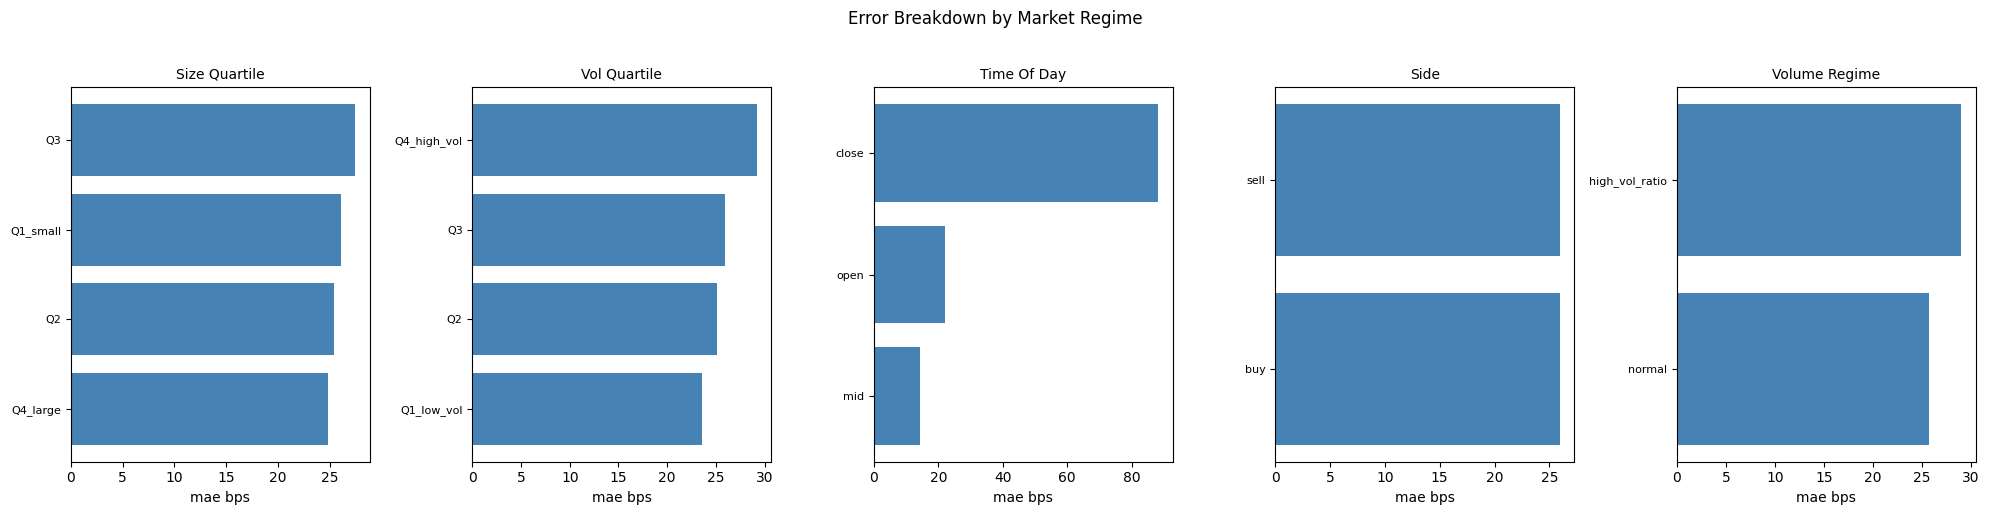

In [7]:
# Error breakdown by segment
breakdown = segment_breakdown(y_test, y_pred_mlp, test_df)
print(breakdown.to_string(index=False))
fig = plot_error_by_segment(breakdown, metric='mae_bps', save_as='error_by_segment.png')
plt.show()

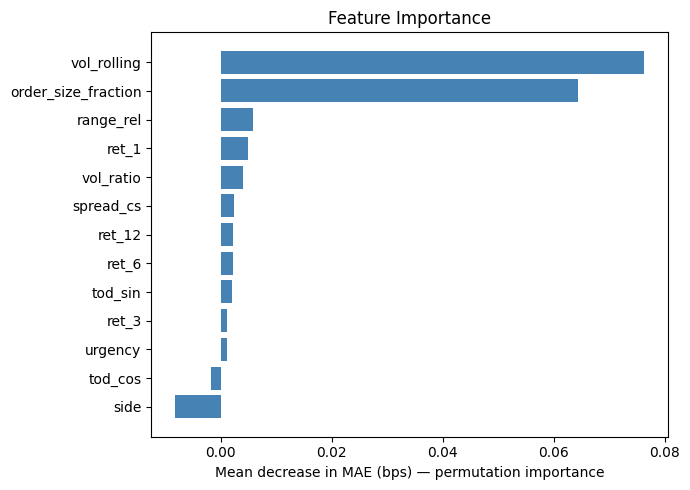

All figures saved to results/figures/


In [8]:
# Feature importance (permutation, on val set)
fig = plot_feature_importance(
    model, split.X_val, split.y_val, FEATURE_NAMES,
    n_repeats=5, seed=42, save_as='feature_importance.png',
)
plt.show()
print('All figures saved to results/figures/')